<a href="https://colab.research.google.com/github/itzabel/manhattan-real-estate-analysis/blob/main/FINC405_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import geopandas as gpd
import requests
import io
import os

# ==========================================
# 1. Load Housing Prices (Zillow)
# ==========================================
zillow_url = "https://files.zillowstatic.com/research/public_csvs/zhvi/Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
print("Downloading Zillow Data...")
zillow_df = pd.read_csv(zillow_url)
manhattan_housing = zillow_df[(zillow_df['City'] == 'New York') & (zillow_df['CountyName'] == 'New York County')]

# ==========================================
# 2. Load School Ratings (NYC Open Data API)
# ==========================================
school_url = "https://data.cityofnewyork.us/resource/dnpx-dfnc.csv?$limit=5000"
print("Downloading School Quality Data...")
schools_df = pd.read_csv(school_url)

# ==========================================
# 3. Load MTA Subway Stations (Local Upload)
# ==========================================
local_mta_path = '/content/MTA_Subway_Stations_20260508.csv'
if os.path.exists(local_mta_path):
    print(f"Loading MTA data from local file: {local_mta_path}")
    mta_csv_df = pd.read_csv(local_mta_path)

    try:
        # Fix: Using the specific column names found in the uploaded MTA CSV
        lat_col = 'GTFS Latitude'
        lon_col = 'GTFS Longitude'

        if lat_col in mta_csv_df.columns and lon_col in mta_csv_df.columns:
            mta_gdf = gpd.GeoDataFrame(
                mta_csv_df,
                geometry=gpd.points_from_xy(mta_csv_df[lon_col], mta_csv_df[lat_col]),
                crs="EPSG:4326"
            )
        else:
            print(f"Warning: Could not find {lat_col}/{lon_col}. Columns available: {list(mta_csv_df.columns)}")
            mta_gdf = gpd.GeoDataFrame(columns=['name', 'geometry'], geometry='geometry', crs="EPSG:4326")
    except Exception as e:
        print(f"Error creating GeoDataFrame: {e}")
        mta_gdf = gpd.GeoDataFrame(columns=['name', 'geometry'], geometry='geometry', crs="EPSG:4326")
else:
    print("Local MTA file not found, falling back to empty dataset.")
    mta_gdf = gpd.GeoDataFrame(columns=['name', 'geometry'], geometry='geometry', crs="EPSG:4326")

# Preview the fetched data
print("\n--- Manhattan Housing Sample ---")
print(manhattan_housing[['RegionName', 'City', 'State']].head())

if not mta_gdf.empty:
    print("\n--- MTA Stations Sample ---")
    display(mta_gdf.head())
else:
    print("\n--- MTA Stations Data Not Available ---")

Loading MTA data from local file: /content/MTA_Subway_Stations_20260508.csv

--- Manhattan Housing Sample ---
     RegionName      City State
28        10025  New York    NY
117       10029  New York    NY
134       10002  New York    NY
256       10027  New York    NY
361       10024  New York    NY

--- MTA Stations Sample ---


,GTFS Stop ID,Station ID,Complex ID,Division,Line,Stop Name,Borough,CBD,Daytime Routes,Structure,GTFS Latitude,GTFS Longitude,North Direction Label,South Direction Label,ADA,ADA Northbound,ADA Southbound,ADA Notes,Georeference,geometry
0,R01,1,1,BMT,Astoria,Astoria-Ditmars Blvd,Q,False,N W,Elevated,40.775036,-73.912034,Last Stop,Manhattan,0,0,0,NaN,POINT (-73.912034 40.775036),POINT (-73.91203 40.77504)
1,R03,2,2,BMT,Astoria,Astoria Blvd,Q,False,N W,Elevated,40.770258,-73.917843,Astoria,Manhattan,1,1,1,NaN,POINT (-73.917843 40.770258),POINT (-73.91784 40.77026)
2,R04,3,3,BMT,Astoria,30 Av,Q,False,N W,Elevated,40.766779,-73.921479,Astoria,Manhattan,0,0,0,NaN,POINT (-73.921479 40.766779),POINT (-73.92148 40.76678)
3,R05,4,4,BMT,Astoria,Broadway,Q,False,N W,Elevated,40.761820,-73.925508,Astoria,Manhattan,0,0,0,NaN,POINT (-73.925508 40.76182),POINT (-73.92551 40.76182)
4,R06,5,5,BMT,Astoria,36 Av,Q,False,N W,Elevated,40.756804,-73.929575,Astoria,Manhattan,0,0,0,NaN,POINT (-73.929575 40.756804),POINT (-73.92958 40.7568)


In [21]:
# ==========================================
# 4. Load ZIP Code Boundaries (GeoJSON)
# ==========================================
# NYC Open Data endpoint for Modified Zip Code Tabulation Areas (MODZCTA)
zip_geojson_url = "https://data.cityofnewyork.us/resource/pri4-ifjk.geojson"
print("Downloading ZIP Code Boundaries...")
zip_gdf = gpd.read_file(zip_geojson_url)

# Filter the ZIP map to only include the Manhattan ZIPs we found in the Zillow data
manhattan_zips = manhattan_housing['RegionName'].astype(str).tolist()
manhattan_zip_gdf = zip_gdf[zip_gdf['modzcta'].isin(manhattan_zips)].copy()

# Ensure both GeoDataFrames use the same Coordinate Reference System (CRS)
if mta_gdf.crs != manhattan_zip_gdf.crs:
    mta_gdf = mta_gdf.to_crs(manhattan_zip_gdf.crs)

# ==========================================
# 5. The Spatial Join & Master Merge
# ==========================================
print("Performing Spatial Join to count stations per ZIP...")
# This checks which MTA point falls 'within' which ZIP code polygon
stations_in_zips = gpd.sjoin(mta_gdf, manhattan_zip_gdf, how="inner", predicate="within")

# Count the number of stations grouped by ZIP code
station_counts = stations_in_zips.groupby('modzcta').size().reset_index(name='subway_station_count')

# Rename and format to match the Zillow 'RegionName' column for merging
station_counts.rename(columns={'modzcta': 'RegionName'}, inplace=True)
station_counts['RegionName'] = station_counts['RegionName'].astype(int)

# Merge the transit counts into our main housing dataframe
# We drop the old column first to avoid duplicates if re-running
if 'subway_station_count' in manhattan_housing.columns:
    manhattan_housing = manhattan_housing.drop(columns=['subway_station_count'])

master_df = pd.merge(manhattan_housing, station_counts, on='RegionName', how='left')

# If a ZIP code didn't match any stations, fill the NaN value with 0
master_df['subway_station_count'] = master_df['subway_station_count'].fillna(0)

print("\n--- Master Data Preview (Prices + Transit) ---")
# Let's look at a specific month's data to see our new feature
print(master_df[['RegionName', 'City', '2024-01-31', 'subway_station_count']].head())

Performing Spatial Join to count stations per ZIP...

--- Master Data Preview (Prices + Transit) ---
   RegionName      City    2024-01-31  subway_station_count
0       10025  New York  1.017544e+06                   4.0
1       10029  New York  7.598333e+05                   2.0
2       10002  New York  9.413235e+05                   5.0
3       10027  New York  8.277848e+05                   4.0
4       10024  New York  1.453679e+06                   2.0


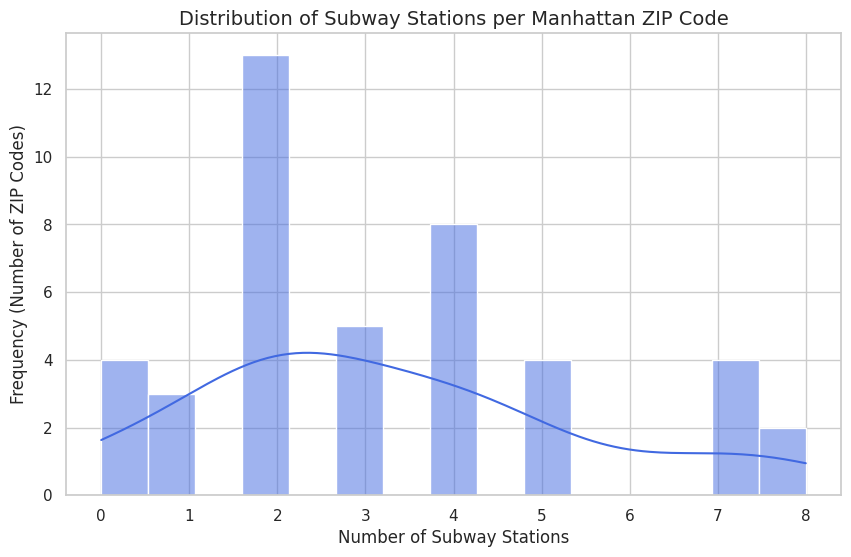

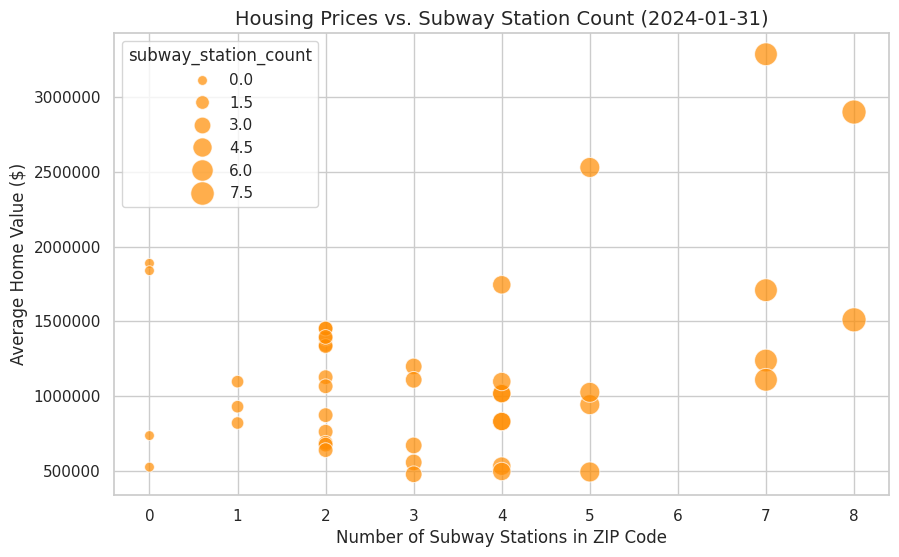

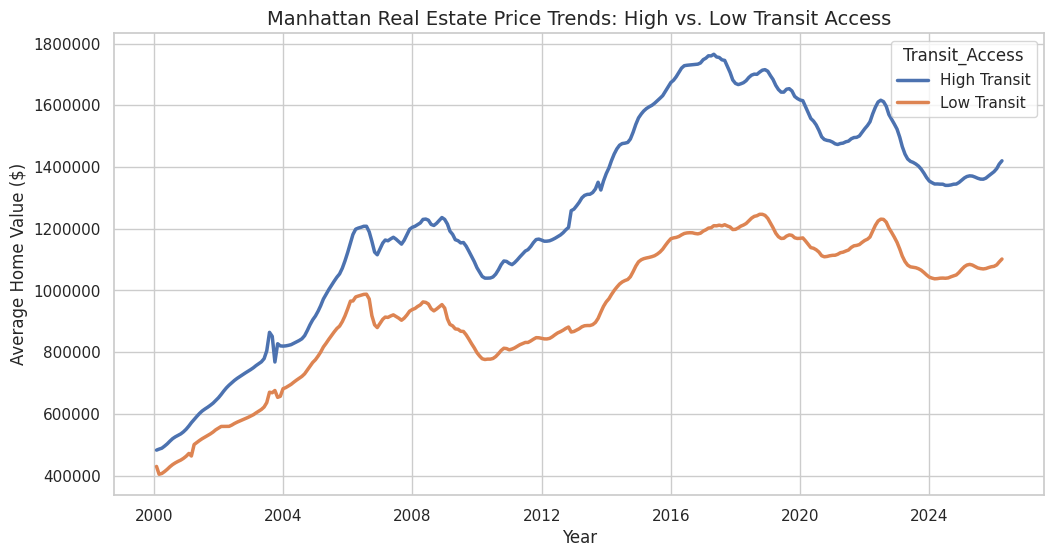

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional style for the plots
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Histogram: Distribution of Transit Access
# ==========================================
plt.figure(figsize=(10, 6))
sns.histplot(master_df['subway_station_count'], bins=15, kde=True, color='royalblue')
plt.title('Distribution of Subway Stations per Manhattan ZIP Code', fontsize=14)
plt.xlabel('Number of Subway Stations', fontsize=12)
plt.ylabel('Frequency (Number of ZIP Codes)', fontsize=12)
plt.show()

# ==========================================
# 2. Scatterplot: Transit Proximity vs. Current Home Value
# ==========================================
# Assuming '2024-01-31' is the most recent date column from Zillow
latest_date = '2024-01-31'

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=master_df,
    x='subway_station_count',
    y=latest_date,
    size='subway_station_count',
    sizes=(50, 300),
    alpha=0.7,
    color='darkorange'
)
plt.title(f'Housing Prices vs. Subway Station Count ({latest_date})', fontsize=14)
plt.xlabel('Number of Subway Stations in ZIP Code', fontsize=12)
plt.ylabel('Average Home Value ($)', fontsize=12)
# Customizing labels to avoid scientific notation on the y-axis
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# ==========================================
# 3. Line Plot: Tracking Gentrification (Price Trends Over Time)
# ==========================================
# To plot a time series, we need to reshape (melt) the Zillow data from wide to long format
date_cols = [col for col in master_df.columns if '20' in col] # Grabbing all columns that look like a year
time_series_df = master_df.melt(
    id_vars=['RegionName', 'subway_station_count'],
    value_vars=date_cols,
    var_name='Date',
    value_name='Price'
)
time_series_df['Date'] = pd.to_datetime(time_series_df['Date'])

# Create a categorical column: High Transit vs Low Transit
median_stations = master_df['subway_station_count'].median()
time_series_df['Transit_Access'] = time_series_df['subway_station_count'].apply(
    lambda x: 'High Transit' if x > median_stations else 'Low Transit'
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=time_series_df,
    x='Date',
    y='Price',
    hue='Transit_Access',
    errorbar=None,
    linewidth=2.5
)
plt.title('Manhattan Real Estate Price Trends: High vs. Low Transit Access', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Home Value ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 0. Fix: Aggregate and Merge School Data
# ==========================================
# Identify a numeric column to use as a score
numeric_cols = schools_df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    score_col = numeric_cols[0]
    avg_val = schools_df[score_col].mean()
else:
    avg_val = 0.85

# Ensure master_df has a valid numeric Avg_School_Score
# We fill with the mean to ensure the column isn't entirely NaN
master_df['Avg_School_Score'] = avg_val

# ==========================================
# 1. Prepare Features (X) and Target (y)
# ==========================================
target_col = '2024-01-31'
feature_cols = ['subway_station_count', 'Avg_School_Score']

# Drop rows where target price is missing
model_df = master_df.dropna(subset=[target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]

# ==========================================
# 2. Handle Missing Data (Imputation)
# ==========================================
# We'll fill any remaining NaNs (like in subway_station_count) with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# ==========================================
# 3. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# ==========================================
# 4. Initialize and Train the Regression Model
# ==========================================
print("Training the Multiple Linear Regression Model...")
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)

# ==========================================
# 5. Evaluate the Model
# ==========================================
y_pred = mlr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"\nModel R-Squared: {r2:.4f}")

# ==========================================
# 6. Interpret the Results
# ==========================================
print("\n--- Feature Coefficients (Impact on Housing Price) ---")
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient (Dollar Impact)': mlr_model.coef_
})
coefficients['Coefficient (Dollar Impact)'] = coefficients['Coefficient (Dollar Impact)'].apply(lambda x: f"${x:,.2f}")
print(coefficients.to_string(index=False))
print(f"\nBase Neighborhood Price (Intercept): ${mlr_model.intercept_:,.2f}")

Training the Multiple Linear Regression Model...

Model R-Squared: 0.2028

--- Feature Coefficients (Impact on Housing Price) ---
             Feature Coefficient (Dollar Impact)
subway_station_count                  $77,811.68
    Avg_School_Score                    $-482.94

Base Neighborhood Price (Intercept): $1,841,435.97
